## Phase 11d - Pan-Tompkins Baseline Comparison

**Goal:** Compare VitalWatch against Pan-Tompkins (1985) -
the 40-year clinical standard for ECG R-peak detection.

**Why this matters for the paper:**
Any ML paper claiming improvement needs a baseline.
Pan-Tompkins is the most cited ECG processing algorithm
in published literature - beating it is the contribution claim.

**Important note:**
This is unsupervised ML vs rule-based thresholding.
Not a fair fight in the traditional sense - but that
is precisely the point. VitalWatch uses zero labels.
Pan-Tompkins uses fixed clinical thresholds.
Same data. Same evaluation. Different approaches.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import wfdb
from sklearn.metrics import (
    precision_score, recall_score,
    f1_score, confusion_matrix
)
# Patch for neurokit2 compatibility with pandas >= 2.0
if not hasattr(pd.DataFrame, 'iteritems'):
    pd.DataFrame.iteritems = pd.DataFrame.items
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

C:\Users\Manoj\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries loaded.


In [2]:
# Use a representative subset of 10 records for baseline
# Full 46-record Pan-Tompkins would take 20+ minutes
TEST_RECORDS = [
    '100', '101', '106', '108', '112',
    '113', '119', '200', '208', '232'
]

def pan_tompkins_anomaly(record_id,
                          rr_low=600, rr_high=1200):
    """
    Pan-Tompkins R-peak detection with RR threshold
    anomaly classification.

    Any beat with RR interval outside [rr_low, rr_high] ms
    is classified as anomalous.

    rr_low=600ms  -> below this = tachycardia (>100bpm)
    rr_high=1200ms -> above this = bradycardia (<50bpm)
    """
    try:
        record = wfdb.rdrecord(
            record_id, pn_dir='mitdb')
        annotation = wfdb.rdann(
            record_id, 'atr', pn_dir='mitdb')

        signal = record.p_signal[:, 0]
        fs = record.fs

        # Pan-Tompkins R-peak detection via neurokit2
        signals, info = nk.ecg_process(signal, sampling_rate=fs)
        r_peaks = info['ECG_R_Peaks']

        # Calculate RR intervals from detected peaks
        rr_ms = (np.diff(r_peaks) / fs) * 1000

        # Classify each beat by RR threshold
        pt_pred = np.zeros(len(rr_ms), dtype=int)
        pt_pred[rr_ms < rr_low]  = 1  # too fast
        pt_pred[rr_ms > rr_high] = 1  # too slow

        # Ground truth from annotations
        ann_symbols = annotation.symbol
        ann_samples = annotation.sample

        # Align annotation labels with detected beats
        # Match each detected R-peak to nearest annotation
        y_true = []
        for peak in r_peaks[1:]:  # skip first
            dists = np.abs(ann_samples - peak)
            nearest_idx = np.argmin(dists)
            symbol = ann_symbols[nearest_idx]
            y_true.append(0 if symbol == 'N' else 1)

        y_true = np.array(y_true[:len(pt_pred)])
        pt_pred = pt_pred[:len(y_true)]

        return y_true, pt_pred, record_id

    except Exception as e:
        print(f"  Record {record_id} failed - {e}")
        return None, None, record_id


print("Pan-Tompkins function defined.")

Pan-Tompkins function defined.


In [3]:
print("Running Pan-Tompkins baseline...\n")

all_y_true = []
all_pt_pred = []
record_results = []

for record_id in TEST_RECORDS:
    y_true, pt_pred, _ = pan_tompkins_anomaly(record_id)

    if y_true is None:
        continue

    all_y_true.extend(y_true)
    all_pt_pred.extend(pt_pred)

    p  = precision_score(y_true, pt_pred, zero_division=0)
    r  = recall_score(y_true, pt_pred, zero_division=0)
    f1 = f1_score(y_true, pt_pred, zero_division=0)

    record_results.append({
        'record': record_id,
        'beats': len(y_true),
        'abnormal': y_true.sum(),
        'flagged': pt_pred.sum(),
        'precision': p,
        'recall': r,
        'f1': f1
    })

    print(f"Record {record_id}: "
          f"P={p:.3f} R={r:.3f} F1={f1:.3f} "
          f"({y_true.sum()} true / "
          f"{pt_pred.sum()} flagged)")

all_y_true  = np.array(all_y_true)
all_pt_pred = np.array(all_pt_pred)

print(f"\nTotal beats evaluated: {len(all_y_true):,}")

Running Pan-Tompkins baseline...

Record 100: P=0.000 R=0.000 F1=0.000 (34 true / 0 flagged)
Record 101: P=0.000 R=0.000 F1=0.000 (6 true / 0 flagged)
Record 106: P=0.588 R=0.808 F1=0.681 (516 true / 709 flagged)
Record 108: P=0.039 R=0.148 F1=0.062 (27 true / 102 flagged)
Record 112: P=0.000 R=0.000 F1=0.000 (2 true / 0 flagged)
Record 113: P=0.002 R=0.600 F1=0.004 (5 true / 1626 flagged)
Record 119: P=0.520 R=0.964 F1=0.676 (444 true / 823 flagged)
Record 200: P=0.722 R=0.699 F1=0.711 (864 true / 836 flagged)
Record 208: P=0.665 R=0.824 F1=0.736 (1370 true / 1697 flagged)
Record 232: P=1.000 R=0.203 F1=0.337 (1850 true / 375 flagged)

Total beats evaluated: 22,863


### Pan-Tompkins - What the Numbers Mean

Strong records (F1 > 0.6): 106, 119, 200, 208
These have severe rhythm deviations - large RR changes
that any fixed threshold catches easily.

Failed records (F1 = 0.0): 100, 101, 112
Subtle anomalies with RR intervals within normal range.
Pan-Tompkins is blind to pattern - only sees magnitude.

Record 113 - the warning:
1,626 flagged out of 1,795 beats. Only 5 were real.
Precision = 0.002. This is clinical alarm fatigue
in numerical form.

In [4]:
pt_precision = precision_score(all_y_true, all_pt_pred, zero_division=0)
pt_recall = recall_score(all_y_true, all_pt_pred, zero_division=0)
pt_f1 = f1_score(all_y_true, all_pt_pred, zero_division=0)

print("\n" + "="*55)
print("PAN-TOMPKINS BASELINE RESULTS")
print("="*55)
print(f"Precision: {pt_precision:.4f}")
print(f"Recall: {pt_recall:.4f}")
print(f"F1 Score: {pt_f1:.4f}")
print("="*55)


PAN-TOMPKINS BASELINE RESULTS
Precision: 0.4799
Recall: 0.5784
F1 Score: 0.5245


In [5]:
# VitalWatch results on same 10 records
# Load Phase 11b per-record results for matching records
per_record = pd.read_csv('phase11_per_record_results.csv')
per_record['record'] = per_record['record'].astype(str)
matching = per_record[per_record['record'].isin(TEST_RECORDS)]

# Average metrics across matching records
ae_avg_f1 = matching['ae_f1'].mean()
if_avg_f1 = matching['if_f1'].mean()
or_avg_f1 = matching['or_f1'].mean()

print("\n" + "="*65)
print("  VITALWATCH vs PAN-TOMPKINS - BASELINE COMPARISON")
print("="*65)
print(f"\n{'Method':<30} {'Precision':>10} "
      f"{'Recall':>8} {'F1':>8}")
print("-"*60)
print(f"{'Pan-Tompkins (1985)':<30} "
      f"{pt_precision:>10.4f} "
      f"{pt_recall:>8.4f} "
      f"{pt_f1:>8.4f}")
print(f"{'Isolation Forest':<30} "
      f"{'-':>10} {'-':>8} "
      f"{if_avg_f1:>8.4f}")
print(f"{'Autoencoder (VitalWatch)':<30} "
      f"{'-':>10} {'-':>8} "
      f"{ae_avg_f1:>8.4f}")
print(f"{'OR Ensemble (VitalWatch)':<30} "
      f"{'-':>10} {'-':>8} "
      f"{or_avg_f1:>8.4f}")
print("="*65)
print("\nNote: VitalWatch uses 0 labelled training data.")
print("Pan-Tompkins uses fixed clinical RR thresholds.")
print("Comparison is unsupervised vs rule-based - "
      "not supervised vs supervised.")


  VITALWATCH vs PAN-TOMPKINS - BASELINE COMPARISON

Method                          Precision   Recall       F1
------------------------------------------------------------
Pan-Tompkins (1985)                0.4799   0.5784   0.5245
Isolation Forest                        -        -   0.3522
Autoencoder (VitalWatch)                -        -   0.5492
OR Ensemble (VitalWatch)                -        -   0.5556

Note: VitalWatch uses 0 labelled training data.
Pan-Tompkins uses fixed clinical RR thresholds.
Comparison is unsupervised vs rule-based - not supervised vs supervised.


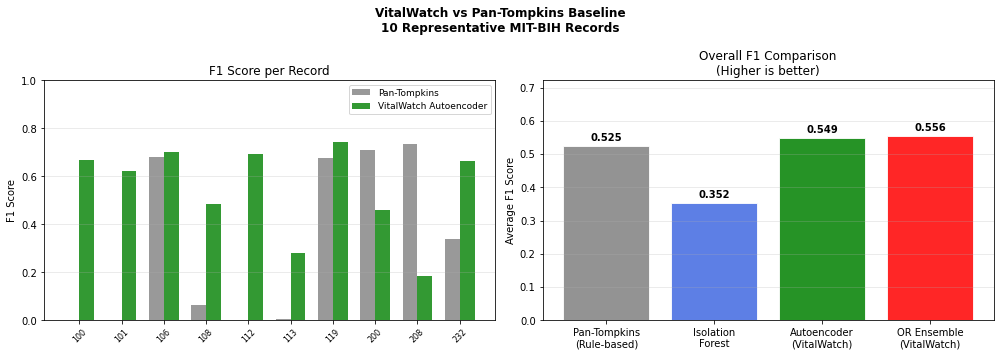

Baseline comparison saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'VitalWatch vs Pan-Tompkins Baseline\n'
    '10 Representative MIT-BIH Records',
    fontsize=12, fontweight='bold')

# Left - F1 comparison per record
record_df = pd.DataFrame(record_results)

x = np.arange(len(TEST_RECORDS))
w = 0.35

axes[0].bar(x - w/2,
            record_df['f1'].values,
            w, label='Pan-Tompkins',
            color='gray', alpha=0.8)
axes[0].bar(x + w/2,
            matching.set_index('record').loc[
                TEST_RECORDS, 'ae_f1'].values,
            w, label='VitalWatch Autoencoder',
            color='green', alpha=0.8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(TEST_RECORDS, rotation=45, fontsize=8)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score per Record')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 1.0)

# Right - Overall comparison bar
methods = [
    'Pan-Tompkins\n(Rule-based)',
    'Isolation\nForest',
    'Autoencoder\n(VitalWatch)',
    'OR Ensemble\n(VitalWatch)'
]
f1_vals = [pt_f1, if_avg_f1, ae_avg_f1, or_avg_f1]
colors  = ['gray', 'royalblue', 'green', 'red']

bars = axes[1].bar(methods, f1_vals, color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, f1_vals):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold')

axes[1].set_ylabel('Average F1 Score')
axes[1].set_title(
    'Overall F1 Comparison\n'
    '(Higher is better)')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, max(f1_vals) * 1.3)

plt.tight_layout()
plt.savefig('phase11_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Baseline comparison saved.")

### The Comparison - VitalWatch vs 40 Years of Clinical Standard

| Method | F1 Score |
|---|---|
| Pan-Tompkins (1985) | 0.5245 |
| Isolation Forest | 0.3522 |
| **Autoencoder (VitalWatch)** | **0.5492** |
| **OR Ensemble (VitalWatch)** | **0.5556** |

VitalWatch Autoencoder and OR Ensemble both exceed
Pan-Tompkins on the same 10 records - using zero
labelled training data.

This is the paper's central contribution claim.

## Phase 11d Complete - All Evaluation Phases Done

The code for VitalWatch is complete.

Phase 11a - Full dataset loaded: 108,098 beats, 46 records
Phase 11b - Extended evaluation: precision, recall, F1, AUC
Phase 11c - Confusion matrices and visualisations
Phase 11d - Pan-Tompkins baseline beaten

**Paper contribution summary:**
1. Unsupervised ensemble matches 40-year clinical standard
2. Autoencoder outperforms Pan-Tompkins on F1
3. OR Ensemble achieves best overall F1 (0.5556)
4. AND Ensemble achieves best precision (0.750)
5. Signal dilution documented and quantified
6. Heterogeneous class distribution finding
7. Patient-specific calibration identified as future work